In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("Palo Alto Networks.csv")

# Basic Information
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset:
(1470, 31)

Column Names:
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

First 5 Rows:
   Age  Attrition     BusinessTravel  DailyRate              Department  \
0   41          1      Travel_Rarely       1102                   Sales   
1   49          0  Travel_Frequently        279  Research & Development   
2   37          1      Travel_Rarely       1373  Research & Development   

In [2]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Data types
print("\nData Types:")
print(df.dtypes)

# Statistical Summary
print("\nStatistical Summary:")
print(df.describe())

# Unique values in categorical columns
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())

Duplicate Rows: 0

Data Types:
Age                          int64
Attrition                    int64
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StockOptionLevel             int64
TotalWorkingYears            int64
TrainingTimesLastYear        int64
WorkLifeBalance              int64
YearsAtCompany          

In [3]:
# Create a safe denominator
df['YearsAtCompany_Safe'] = df['YearsAtCompany'].replace(0, 0.1)

# 1. Promotion Gap Ratio
df['PromotionGapRatio'] = (
    df['YearsSinceLastPromotion'] /
    df['YearsAtCompany_Safe']
)

# 2. Role Stagnation Index
df['RoleStagnationIndex'] = (
    df['YearsInCurrentRole'] /
    df['YearsAtCompany_Safe']
)

# 3. Training Intensity Score
df['TrainingIntensityScore'] = (
    df['TrainingTimesLastYear'] /
    df['YearsAtCompany_Safe']
)

# 4. Manager Stability Indicator
df['ManagerStabilityIndicator'] = (
    df['YearsWithCurrManager'] /
    df['YearsAtCompany_Safe']
)

# Display new features
print(df[['PromotionGapRatio',
          'RoleStagnationIndex',
          'TrainingIntensityScore',
          'ManagerStabilityIndicator']].head())

   PromotionGapRatio  RoleStagnationIndex  TrainingIntensityScore  \
0              0.000             0.666667                   0.000   
1              0.100             0.700000                   0.300   
2              0.000             0.000000                  30.000   
3              0.375             0.875000                   0.375   
4              1.000             1.000000                   1.500   

   ManagerStabilityIndicator  
0                   0.833333  
1                   0.700000  
2                   0.000000  
3                   0.000000  
4                   1.000000  


In [4]:
print(df[['PromotionGapRatio',
          'RoleStagnationIndex',
          'TrainingIntensityScore',
          'ManagerStabilityIndicator']].describe())

       PromotionGapRatio  RoleStagnationIndex  TrainingIntensityScore  \
count        1470.000000          1470.000000             1470.000000   
mean            0.290232             0.578220                1.759549   
std             0.340521             0.331966                5.998544   
min             0.000000             0.000000                0.000000   
25%             0.000000             0.352500                0.250000   
50%             0.166667             0.666667                0.500000   
75%             0.500000             0.833333                1.000000   
max             1.000000             1.000000               60.000000   

       ManagerStabilityIndicator  
count                1470.000000  
mean                    0.558626  
std                     0.334732  
min                     0.000000  
25%                     0.333333  
50%                     0.666667  
75%                     0.800000  
max                     1.000000  


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

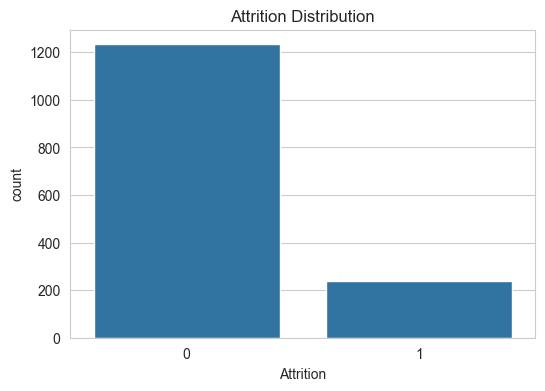

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df)
plt.title('Attrition Distribution')
plt.show()

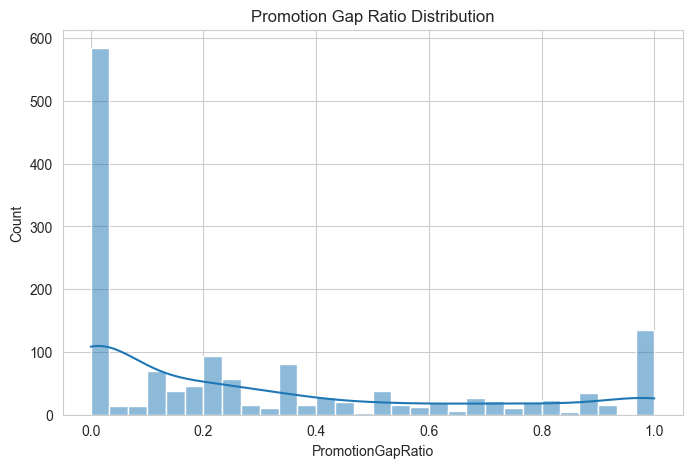

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['PromotionGapRatio'], bins=30, kde=True)
plt.title('Promotion Gap Ratio Distribution')
plt.show()

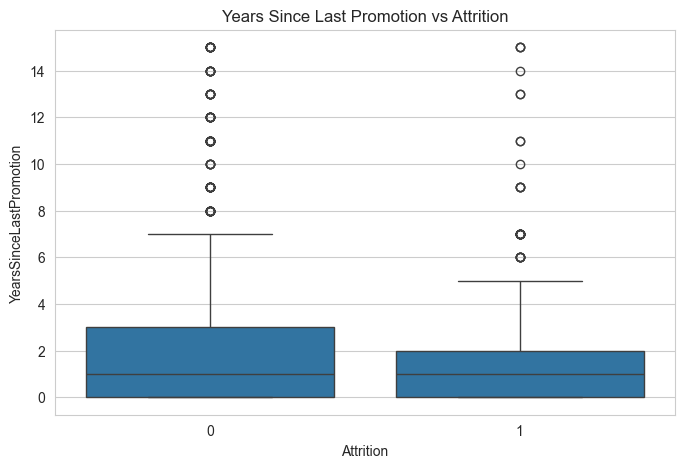

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Attrition',
    y='YearsSinceLastPromotion',
    data=df
)
plt.title('Years Since Last Promotion vs Attrition')
plt.show()

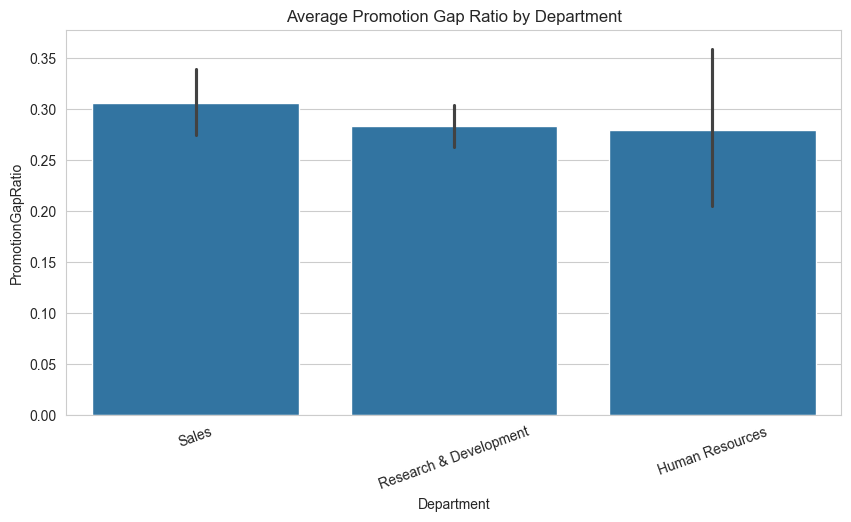

In [9]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Department',
    y='PromotionGapRatio',
    data=df,
    estimator='mean'
)

plt.title('Average Promotion Gap Ratio by Department')
plt.xticks(rotation=20)
plt.show()

In [10]:
from sklearn.preprocessing import StandardScaler

cluster_features = [
    'PromotionGapRatio',
    'RoleStagnationIndex',
    'TrainingIntensityScore',
    'ManagerStabilityIndicator',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager',
    'JobLevel',
    'MonthlyIncome'
]

X = df[cluster_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape of Scaled Data:")
print(X_scaled.shape)

Shape of Scaled Data:
(1470, 10)


In [11]:
import pandas as pd

scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)

print(scaled_df.describe().round(2))

       PromotionGapRatio  RoleStagnationIndex  TrainingIntensityScore  \
count            1470.00              1470.00                 1470.00   
mean                0.00                 0.00                    0.00   
std                 1.00                 1.00                    1.00   
min                -0.85                -1.74                   -0.29   
25%                -0.85                -0.68                   -0.25   
50%                -0.36                 0.27                   -0.21   
75%                 0.62                 0.77                   -0.13   
max                 2.09                 1.27                    9.71   

       ManagerStabilityIndicator  YearsAtCompany  YearsInCurrentRole  \
count                    1470.00         1470.00             1470.00   
mean                       -0.00           -0.00                0.00   
std                         1.00            1.00                1.00   
min                        -1.67           -1.14      

In [12]:
print(X_scaled.shape)

(1470, 10)


In [13]:
scaled_df.head()

,PromotionGapRatio,RoleStagnationIndex,TrainingIntensityScore,ManagerStabilityIndicator,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,JobLevel,MonthlyIncome
0,-0.852607,0.266524,-0.293429,0.820959,-0.164613,-0.063296,-0.679146,0.245834,-0.057788,-0.108350
1,-0.558839,0.366970,-0.243400,0.422495,0.488508,0.764998,-0.368715,0.806541,-0.057788,-0.291719
2,-0.852607,-1.742398,4.709486,-1.669441,-1.144294,-1.167687,-0.679146,-1.155935,-0.961486,-0.937654
3,0.249022,0.894312,-0.230893,-1.669441,0.161947,0.764998,0.252146,-1.155935,-0.961486,-0.763634
4,2.085070,1.270985,-0.043283,1.319039,-0.817734,-0.615492,-0.058285,-0.595227,-0.961486,-0.644858


C:\Users\Abirami\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Abirami\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^

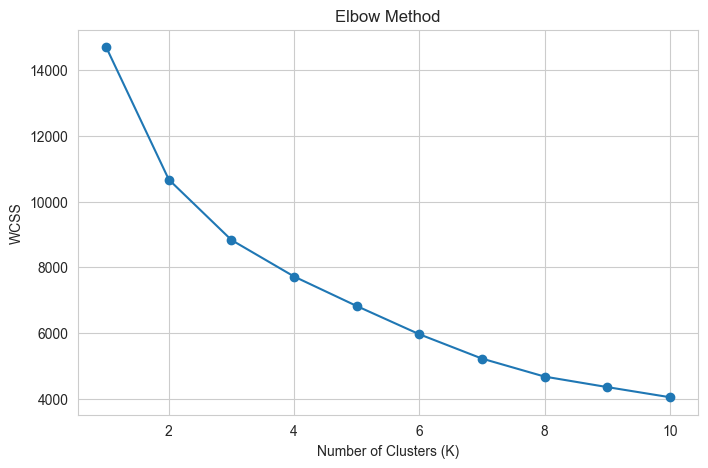

In [14]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [15]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df['CareerCluster'] = kmeans.fit_predict(X_scaled)

print(df['CareerCluster'].value_counts().sort_index())

CareerCluster
0    259
1    591
2    154
3    275
4    191
Name: count, dtype: int64


In [16]:
print(
    df.groupby('CareerCluster')[[
        'PromotionGapRatio',
        'RoleStagnationIndex',
        'TrainingIntensityScore',
        'ManagerStabilityIndicator',
        'YearsAtCompany',
        'YearsSinceLastPromotion',
        'JobLevel',
        'MonthlyIncome'
    ]].mean().round(2)
)

               PromotionGapRatio  RoleStagnationIndex  TrainingIntensityScore  \
CareerCluster                                                                   
0                           0.87                 0.81                    0.84   
1                           0.12                 0.59                    0.71   
2                           0.42                 0.50                    0.17   
3                           0.19                 0.78                    0.28   
4                           0.07                 0.00                    9.67   

               ManagerStabilityIndicator  YearsAtCompany  \
CareerCluster                                              
0                                   0.78            5.20   
1                                   0.55            4.78   
2                                   0.49           19.51   
3                                   0.79           10.75   
4                                   0.00            0.87   

           

In [17]:
df['CareerCluster'].value_counts().sort_index()

CareerCluster
0    259
1    591
2    154
3    275
4    191
Name: count, dtype: int64

In [18]:
df.groupby('CareerCluster')[...].mean()

KeyError: 'Column not found: Ellipsis'

In [19]:
cluster_summary = df.groupby('CareerCluster')[[
    'PromotionGapRatio',
    'RoleStagnationIndex',
    'TrainingIntensityScore',
    'ManagerStabilityIndicator',
    'YearsAtCompany',
    'YearsSinceLastPromotion',
    'JobLevel',
    'MonthlyIncome'
]].mean().round(2)

print(cluster_summary)

               PromotionGapRatio  RoleStagnationIndex  TrainingIntensityScore  \
CareerCluster                                                                   
0                           0.87                 0.81                    0.84   
1                           0.12                 0.59                    0.71   
2                           0.42                 0.50                    0.17   
3                           0.19                 0.78                    0.28   
4                           0.07                 0.00                    9.67   

               ManagerStabilityIndicator  YearsAtCompany  \
CareerCluster                                              
0                                   0.78            5.20   
1                                   0.55            4.78   
2                                   0.49           19.51   
3                                   0.79           10.75   
4                                   0.00            0.87   

           

In [20]:
def promotion_gap_risk(row):

    if (
        row['PromotionGapRatio'] >= 0.60
        or row['RoleStagnationIndex'] >= 0.75
    ):
        return "High"

    elif (
        row['PromotionGapRatio'] >= 0.30
        or row['RoleStagnationIndex'] >= 0.50
    ):
        return "Medium"

    else:
        return "Low"


df['PromotionGapScore'] = df.apply(
    promotion_gap_risk,
    axis=1
)

print(df['PromotionGapScore'].value_counts())

PromotionGapScore
High      713
Medium    388
Low       369
Name: count, dtype: int64


In [21]:
pd.crosstab(
    df['CareerCluster'],
    df['PromotionGapScore']
)

PromotionGapScore,High,Low,Medium
CareerCluster,,,
0,259,0,0
1,197,136,258
2,68,40,46
3,177,15,83
4,12,178,1


In [22]:
df['PromotionGapScore'].value_counts()

PromotionGapScore
High      713
Medium    388
Low       369
Name: count, dtype: int64

In [23]:
pd.crosstab(
    df['CareerCluster'],
    df['PromotionGapScore']
)

PromotionGapScore,High,Low,Medium
CareerCluster,,,
0,259,0,0
1,197,136,258
2,68,40,46
3,177,15,83
4,12,178,1


In [24]:
# Retention Opportunity Index

df['RetentionOpportunityIndex'] = (
    0.4 * df['PromotionGapRatio']
    + 0.3 * df['RoleStagnationIndex']
    - 0.2 * df['TrainingIntensityScore']
    + 0.1 * df['ManagerStabilityIndicator']
)

In [25]:
def roi_category(score):

    if score >= 0.60:
        return "High Priority"

    elif score >= 0.30:
        return "Medium Priority"

    else:
        return "Low Priority"


df['RetentionPriority'] = df[
    'RetentionOpportunityIndex'
].apply(roi_category)

print(df['RetentionPriority'].value_counts())

RetentionPriority
Low Priority       921
Medium Priority    451
High Priority       98
Name: count, dtype: int64


In [26]:
retention_candidates = df[
    (df['Attrition'] == 0)
    &
    (df['RetentionPriority'] == 'High Priority')
]

print("Employees needing intervention:")
print(retention_candidates.shape[0])

Employees needing intervention:
79


In [27]:
retention_candidates[
    [
        'Age',
        'Department',
        'JobRole',
        'YearsAtCompany',
        'PromotionGapRatio',
        'RoleStagnationIndex',
        'RetentionOpportunityIndex'
    ]
].sort_values(
    by='RetentionOpportunityIndex',
    ascending=False
).head(20)

,Age,Department,JobRole,YearsAtCompany,PromotionGapRatio,RoleStagnationIndex,RetentionOpportunityIndex
596,35,Research & Development,Research Scientist,2,1.000000,1.000000,0.800000
735,48,Research & Development,Healthcare Representative,2,1.000000,1.000000,0.800000
401,56,Sales,Sales Executive,7,1.000000,1.000000,0.800000
770,46,Research & Development,Research Director,2,1.000000,1.000000,0.800000
1360,31,Research & Development,Laboratory Technician,2,1.000000,1.000000,0.800000
882,36,Research & Development,Manufacturing Director,7,1.000000,1.000000,0.742857
263,46,Sales,Manager,7,1.000000,1.000000,0.742857
1361,26,Research & Development,Laboratory Technician,7,1.000000,1.000000,0.714286
9,36,Research & Development,Healthcare Representative,7,1.000000,1.000000,0.714286
1148,39,Research & Development,Manufacturing Director,7,1.000000,1.000000,0.714286


In [28]:
df['RetentionPriority'].value_counts()

RetentionPriority
Low Priority       921
Medium Priority    451
High Priority       98
Name: count, dtype: int64

In [29]:
retention_candidates.shape[0]

79

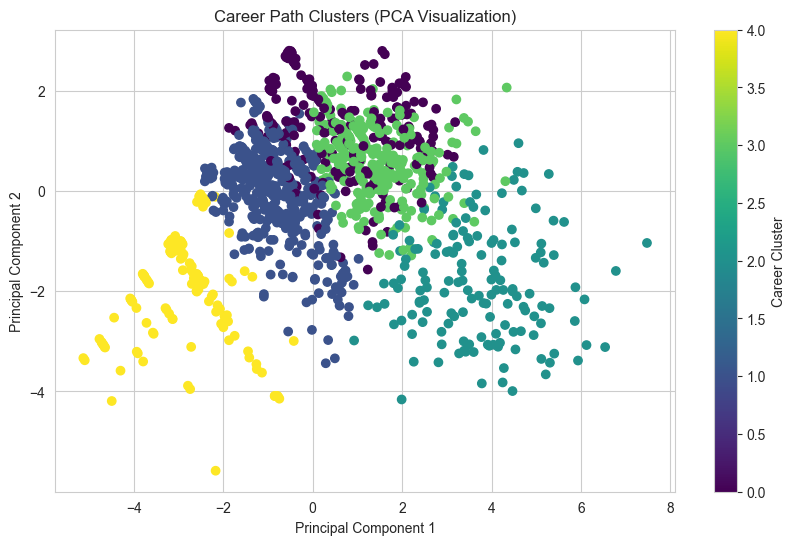

In [30]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

pca_components = pca.fit_transform(X_scaled)

df['PCA1'] = pca_components[:, 0]
df['PCA2'] = pca_components[:, 1]

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df['PCA1'],
    df['PCA2'],
    c=df['CareerCluster'],
    cmap='viridis'
)

plt.title('Career Path Clusters (PCA Visualization)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.colorbar(label='Career Cluster')

plt.show()

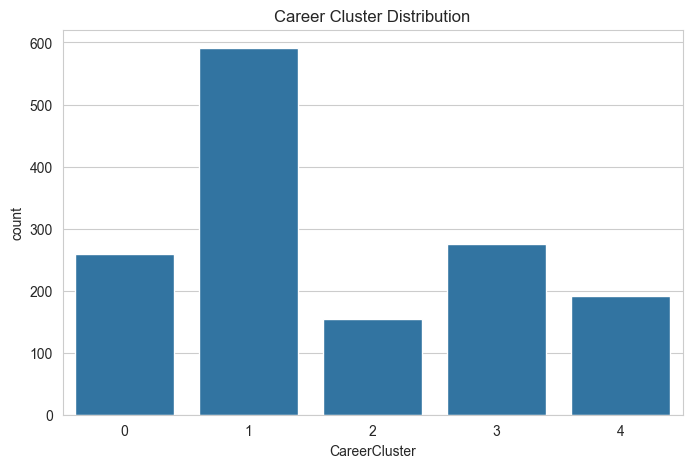

In [31]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    x='CareerCluster',
    data=df
)

plt.title('Career Cluster Distribution')

plt.show()

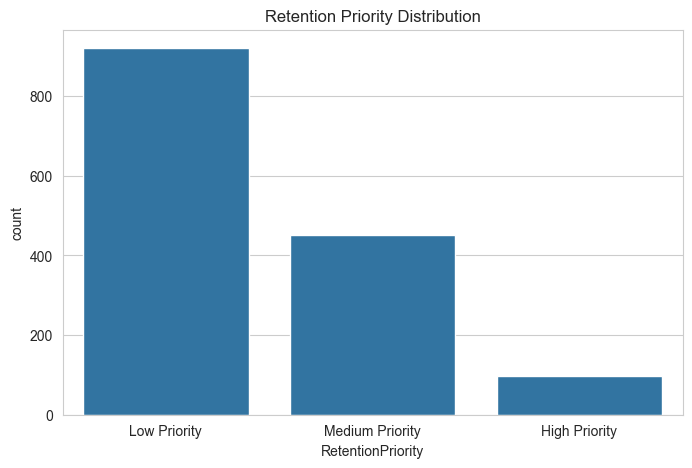

In [32]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='RetentionPriority',
    data=df
)

plt.title('Retention Priority Distribution')

plt.show()

In [33]:
# Career Cluster Distribution
cluster_dist = df['CareerCluster'].value_counts().sort_index()

print(cluster_dist)

print("\n")

# Retention Priority Distribution
priority_dist = df['RetentionPriority'].value_counts()

print(priority_dist)

print("\n")

# Promotion Gap Score Distribution
promotion_dist = df['PromotionGapScore'].value_counts()

print(promotion_dist)

CareerCluster
0    259
1    591
2    154
3    275
4    191
Name: count, dtype: int64


RetentionPriority
Low Priority       921
Medium Priority    451
High Priority       98
Name: count, dtype: int64


PromotionGapScore
High      713
Medium    388
Low       369
Name: count, dtype: int64


In [34]:
department_summary = df.groupby('Department')[
    [
        'PromotionGapRatio',
        'RoleStagnationIndex',
        'RetentionOpportunityIndex'
    ]
].mean().round(2)

print(department_summary)

                        PromotionGapRatio  RoleStagnationIndex  \
Department                                                       
Human Resources                      0.28                 0.55   
Research & Development               0.28                 0.57   
Sales                                0.31                 0.59   

                        RetentionOpportunityIndex  
Department                                         
Human Resources                              0.19  
Research & Development                      -0.01  
Sales                                       -0.02  


In [35]:
top_departments = (
    df.groupby('Department')
    ['RetentionOpportunityIndex']
    .mean()
    .sort_values(ascending=False)
)

print(top_departments)

Department
Human Resources           0.192680
Research & Development   -0.014409
Sales                    -0.017557
Name: RetentionOpportunityIndex, dtype: float64


In [36]:
df.to_csv(
    "Career_Progression_Analysis_Final.csv",
    index=False
)

print("File Saved Successfully")

File Saved Successfully


In [37]:
print(df.columns.tolist())

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'YearsAtCompany_Safe', 'PromotionGapRatio', 'RoleStagnationIndex', 'TrainingIntensityScore', 'ManagerStabilityIndicator', 'CareerCluster', 'PromotionGapScore', 'RetentionOpportunityIndex', 'RetentionPriority', 'PCA1', 'PCA2']


In [38]:
print(df.columns.tolist())

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'YearsAtCompany_Safe', 'PromotionGapRatio', 'RoleStagnationIndex', 'TrainingIntensityScore', 'ManagerStabilityIndicator', 'CareerCluster', 'PromotionGapScore', 'RetentionOpportunityIndex', 'RetentionPriority', 'PCA1', 'PCA2']


In [39]:
cluster_labels = {
    0: "Promotion-Stalled Employees",
    1: "Stable Contributors",
    2: "Senior Long-Term Contributors",
    3: "Career Growth Track",
    4: "Early-Career Explorers"
}

df['CareerClusterLabel'] = df['CareerCluster'].map(cluster_labels)

print(df[['CareerCluster', 'CareerClusterLabel']].head())

   CareerCluster           CareerClusterLabel
0              1          Stable Contributors
1              3          Career Growth Track
2              4       Early-Career Explorers
3              1          Stable Contributors
4              0  Promotion-Stalled Employees


In [40]:
print(df['CareerClusterLabel'].value_counts())

CareerClusterLabel
Stable Contributors              591
Career Growth Track              275
Promotion-Stalled Employees      259
Early-Career Explorers           191
Senior Long-Term Contributors    154
Name: count, dtype: int64


In [41]:
df['CareerClusterLabel'].value_counts()

CareerClusterLabel
Stable Contributors              591
Career Growth Track              275
Promotion-Stalled Employees      259
Early-Career Explorers           191
Senior Long-Term Contributors    154
Name: count, dtype: int64

In [42]:
# Attrition Rate

attrition_rate = (
    df['Attrition'].sum() / len(df)
) * 100

print("Attrition Rate:", round(attrition_rate, 2), "%")


# High Priority Retention Cases

high_priority = (
    df['RetentionPriority']
    == 'High Priority'
).sum()

print("High Priority Employees:", high_priority)


# Active Employees Requiring Intervention

active_intervention = df[
    (df['Attrition'] == 0)
    &
    (df['RetentionPriority'] == 'High Priority')
]

print(
    "Active Employees Requiring Intervention:",
    active_intervention.shape[0]
)

Attrition Rate: 16.12 %
High Priority Employees: 98
Active Employees Requiring Intervention: 79


In [43]:
print("Attrition Rate:", round(attrition_rate, 2), "%")
print("High Priority Employees:", high_priority)
print("Active Employees Requiring Intervention:", active_intervention.shape[0])

Attrition Rate: 16.12 %
High Priority Employees: 98
Active Employees Requiring Intervention: 79


In [44]:
pd.crosstab(
    df['CareerClusterLabel'],
    df['RetentionPriority']
)

RetentionPriority,High Priority,Low Priority,Medium Priority
CareerClusterLabel,,,
Career Growth Track,3,96,176
Early-Career Explorers,0,191,0
Promotion-Stalled Employees,85,26,148
Senior Long-Term Contributors,10,62,82
Stable Contributors,0,546,45


In [45]:
final_findings = {
    "Total Employees": len(df),
    "Attrition Rate (%)": round(
        (df['Attrition'].sum() / len(df)) * 100,
        2
    ),
    "Career Clusters": df['CareerCluster'].nunique(),
    "High Priority Employees": (
        df['RetentionPriority'] == 'High Priority'
    ).sum(),
    "Employees Requiring Intervention": len(
        df[
            (df['Attrition'] == 0)
            &
            (df['RetentionPriority'] == 'High Priority')
        ]
    )
}

print(final_findings)

{'Total Employees': 1470, 'Attrition Rate (%)': 16.12, 'Career Clusters': 5, 'High Priority Employees': 98, 'Employees Requiring Intervention': 79}


In [1]:
print(final_findings)

NameError: name 'final_findings' is not defined